# Red convolucional

In [2]:
# --- IMPORTACIONES ---
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os
import csv
import torch
import kagglehub
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
# --- FRAGMENTO NÚMERO 1 ---
KAGGLE_DATASET_ID = 'pkdarabi/cardetection'
print(f"Descargando dataset: {KAGGLE_DATASET_ID}")
KAGGLE_DOWNLOAD_PATH = kagglehub.dataset_download(KAGGLE_DATASET_ID)
print(f"Dataset descargado en: {KAGGLE_DOWNLOAD_PATH}")

print("\n--- Generando archivos CSV desde los directorios 'labels' ---")
base_data_path = os.path.join(KAGGLE_DOWNLOAD_PATH, "car")
splits_names = ["train", "valid", "test"]
DATA_DIR = './' 

csv_header = ['nombre_archivo', 'clase_indice', 'x_center', 'y_center', 'width', 'height']

for split in splits_names:
    labels_dir = os.path.join(base_data_path, split, "labels")
    
    # Nombre del archivo CSV de salida que queremos crear
    output_csv_file = os.path.join(DATA_DIR, f"./CSVs/labels_{split}.csv")
    
    print(f"Procesando: {labels_dir}")

    if not os.path.exists(labels_dir):
        print(f"  - Advertencia: No se encontró el directorio de etiquetas: {labels_dir}")
        continue

    # Abrimos el nuevo archivo CSV en modo escritura
    with open(output_csv_file, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(csv_header) # Escribimos la cabecera
        
        # Recorremos cada archivo .txt en el directorio de etiquetas
        for txt_filename in os.listdir(labels_dir):
            if txt_filename.endswith('.txt'):
                
                # Asumimos que la imagen tiene el mismo nombre pero con .jpg
                # (o .png, etc., ajusta si es necesario)
                image_filename = txt_filename.replace('.txt', '.jpg')
                txt_filepath = os.path.join(labels_dir, txt_filename)
                
                # Leemos el contenido del archivo .txt
                with open(txt_filepath, 'r') as f_txt:
                    for line in f_txt:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            # 'parts' es [clase, x, y, w, h]
                            clase_idx = parts[0]
                            x_center = parts[1]
                            y_center = parts[2]
                            width = parts[3]
                            height = parts[4]
                            
                            # Escribimos la fila completa en el CSV
                            writer.writerow([image_filename, clase_idx, x_center, y_center, width, height])

    print(f"  - ¡CSV Creado! -> {output_csv_file}")

IMAGE_SIZE = (416, 416)
BATCH_SIZE = 32 # <-- Baja el Batch Size, ResNet consume MÁS VRAM. 32 o 16 es seguro.

# Normalización OBLIGATORIA para modelos pre-entrenados
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# 1. Transformaciones para ENTRENAMIENTO (con aumento de datos)
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5), # Volteo aleatorio
    transforms.RandomRotation(15),           # Rotación aleatoria
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Cambios de color
    transforms.ToTensor(),                   # Convertir a Tensor
    normalize,                               # Normalizar
])

# 2. Transformaciones para VALIDACIÓN y TEST (solo limpiar)
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    normalize,
])

# Esta clase ahora funcionará porque leerá los CSVs que acabamos de crear.
class YOLODataset(Dataset):
    def __init__(self, archivo_csv, directorio_imagenes, transform=None):
        self.directorio_imagenes = directorio_imagenes
        self.transform = transform
        
        try:
            self.full_labels_df = pd.read_csv(archivo_csv)
        except FileNotFoundError:
            print(f"  - ¡Error! No se encontró el archivo CSV: {archivo_csv}")
            self.full_labels_df = pd.DataFrame(columns=['nombre_archivo'])
            
        self.imagenes_unicas = self.full_labels_df['nombre_archivo'].unique()
        self.labels_grouped = self.full_labels_df.groupby('nombre_archivo')

    def __len__(self):
        return len(self.imagenes_unicas)

    def __getitem__(self, idx):
        image_name = self.imagenes_unicas[idx]
        image_path = os.path.join(self.directorio_imagenes, image_name)
        
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            return torch.zeros(3, IMAGE_SIZE[0], IMAGE_SIZE[1]), torch.tensor(-1) 

        boxes_df = self.labels_grouped.get_group(image_name)
        clase_idx = int(boxes_df['clase_indice'].iloc[0])
        label = torch.tensor(clase_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

Descargando dataset: pkdarabi/cardetection
Dataset descargado en: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5

--- Generando archivos CSV desde los directorios 'labels' ---
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\train\labels
  - ¡CSV Creado! -> ././CSVs/labels_train.csv
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\valid\labels
  - ¡CSV Creado! -> ././CSVs/labels_valid.csv
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\test\labels
  - ¡CSV Creado! -> ././CSVs/labels_test.csv


Tras lo anterior hay que dirigirse al *Script* con el nombre [new_csv.py](/new_csv.py) para eliminar la clase 2 (solo 19 imágenes que generan confusión durante el entrenamiento).

In [3]:
# --- FRAGMENTO NÚMERO 2 ---
print("\n--- Cargando Datasets y DataLoaders desde los CSVs generados ---")

datasets = {}
dataloaders = {}

for label in splits_names:
    ruta_csv = os.path.join(DATA_DIR, f"CSVs/{label}_corregido.csv") 
    ruta_imgs = os.path.join(base_data_path, label, "images")
    
    print(f"\nProcesando conjunto de datos: {label}")
    print(f"Ruta del CSV: {ruta_csv}")
    print(f"Ruta de las imágenes: {ruta_imgs}")

    if not os.path.exists(ruta_csv) or not os.path.exists(ruta_imgs):
        print("  - Error: No se encontró el CSV o el directorio de imágenes.")

    else:
        # Asignar la transformación correcta según el split
        if label == 'train':
            transform_actual = train_transform
        else:
            transform_actual = val_transform
            
        dataset_yolo = YOLODataset(archivo_csv=ruta_csv, 
                                   directorio_imagenes=ruta_imgs, 
                                   transform=transform_actual)
        if len(dataset_yolo) > 0:
            print(f"  - Tipo de objeto creado: {type(dataset_yolo)}")
            print(f"  - Número total de imágenes: {len(dataset_yolo)}")

            datasets[label] = dataset_yolo
            dataloaders[label] = DataLoader(
                dataset_yolo,
                batch_size=BATCH_SIZE,
                shuffle=(label == 'train'),
                num_workers=0)
            print(f"  - DataLoader para '{label}' creado.")

        else:
            print("  - Error: El dataset está vacío (CSV vacío o no se pudo leer).")
print("\n--- Proceso completado ---")


--- Cargando Datasets y DataLoaders desde los CSVs generados ---

Procesando conjunto de datos: train
Ruta del CSV: ./CSVs/train_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\train\images
  - Tipo de objeto creado: <class '__main__.YOLODataset'>
  - Número total de imágenes: 3518
  - DataLoader para 'train' creado.

Procesando conjunto de datos: valid
Ruta del CSV: ./CSVs/valid_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\valid\images
  - Tipo de objeto creado: <class '__main__.YOLODataset'>
  - Número total de imágenes: 801
  - DataLoader para 'valid' creado.

Procesando conjunto de datos: test
Ruta del CSV: ./CSVs/test_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\test\images
  - Tipo de objeto creado: <class '__main__.YOLODataset'>
  - Número total de imágenes: 636
  - DataLoader 

In [5]:
# --- Configuración del Loader ---
# BATCH_SIZE = 16 # Tamaño de batch comúnmente usado en detección de objetos.

# Crear el DataLoader
# train_loader = DataLoader(dataset_yolo, batch_size=BATCH_SIZE, shuffle=True)
# print(f"\nTipo de DataLoader creado: {type(train_loader)}")
# 
# print(f"\nDataLoader creado con éxito. Número de batches: {len(train_loader)}")

In [4]:
def create_model(num_classes=14):
    # 1. Cargar ResNet50 pre-entrenado en ImageNet
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # 2. Congelar todos los pesos del modelo
    # No queremos re-entrenar las capas que ya saben detectar bordes, texturas, etc.
    for param in model.parameters():
        param.requires_grad = False

    # 3. Reemplazar la capa final (el "clasificador")
    # Obtenemos las características de entrada de la última capa
    num_ftrs = model.fc.in_features

    # Creamos nuestra propia capa final que SÍ entrenaremos
    # La salida debe ser 14 (tus clases corregidas)
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    print("Modelo ResNet50 pre-entrenado cargado.")
    print("Todas las capas congeladas, excepto la capa final (model.fc).")
    
    return model

In [ ]:
# --- FRAGMENTO NÚMERO 4 (MODIFICADO con Entrenamiento en 2 Fases) ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsando dispositivo: {device}")

# --- Fase 1: Entrenamiento de la Capa Final (Head) ---

EPOCHS_HEAD = 15  # Épocas solo para la capa final
EPOCHS_TUNE = 50  # Épocas para el ajuste fino
LR_HEAD = 0.001
LR_TUNE = 0.00001 # Tasa de aprendizaje MUY baja para el ajuste fino

# Cargar el modelo
model = create_model(num_classes=14).to(device)
criterion = nn.CrossEntropyLoss()

# Asignar los DataLoaders correctos
try:
    train_loader = dataloaders['train']
    valid_loader = dataloaders['valid']
except KeyError:
    print("Error: No se pudieron crear los DataLoaders de 'train' o 'valid'. Saliendo.")
    exit()

# Optimizador SOLO para la capa final (model.fc)
optimizer = optim.AdamW(model.fc.parameters(), lr=LR_HEAD, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

print(f"\n--- Iniciando Fase 1: Entrenamiento de la Capa Final ({EPOCHS_HEAD} épocas) ---")

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(EPOCHS_HEAD):
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_HEAD} [Head Train]", leave=False)
    
    for images, labels in train_loop:
        if -1 in labels: continue
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item())

    # Validación de la Fase 1
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            if -1 in labels: continue
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = (correct_train / total_train) * 100
    avg_val_loss = val_loss / len(valid_loader)
    avg_val_acc = (correct_val / total_val) * 100
    
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS_HEAD} | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.2f}%")
    
    scheduler.step(avg_val_acc)


# --- Fase 2: Ajuste Fino (Fine-Tuning) ---

print(f"\n--- Iniciando Fase 2: Ajuste Fino de todo el modelo ({EPOCHS_TUNE} épocas) ---")

# Descongelar TODAS las capas
for param in model.parameters():
    param.requires_grad = True

# Nuevo optimizador para TODOS los parámetros, con LR muy baja
optimizer = optim.AdamW(model.parameters(), lr=LR_TUNE, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

# Reiniciar variables de Early Stopping
patience = 15
epochs_no_improve = 0
best_val_acc = 0.0 # Reiniciar con el mejor valor de la fase 1 (o 0)
min_delta = 0.01

for epoch in range(EPOCHS_TUNE):
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1+EPOCHS_HEAD}/{EPOCHS_HEAD+EPOCHS_TUNE} [Tune Train]", leave=False)
    
    for images, labels in train_loop:
        if -1 in labels: continue
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item())

    # Validación de la Fase 2
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            if -1 in labels: continue
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = (correct_train / total_train) * 100
    avg_val_loss = val_loss / len(valid_loader)
    avg_val_acc = (correct_val / total_val) * 100
    
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {epoch+1+EPOCHS_HEAD}/{EPOCHS_HEAD+EPOCHS_TUNE} | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.2f}%")

    # Lógica de Scheduler y Early Stopping
    scheduler.step(avg_val_acc)
    
    if avg_val_acc > (best_val_acc + min_delta):
        print(f"  ¡Mejora! Guardando modelo... (Val Acc: {best_val_acc:.2f}% -> {avg_val_acc:.2f}%)")
        torch.save(model.state_dict(), 'best_model.pth')
        best_val_acc = avg_val_acc
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"  Sin mejora. {epochs_no_improve}/{patience} épocas para Early Stop.")

    if epochs_no_improve >= patience:
        print(f"\n--- ¡Early Stopping! ---")
        print(f"No hubo mejora en las últimas {patience} épocas.")
        print(f"Parando entrenamiento.")
        break

print("\n--- Entrenamiento Completado ---")

# Cargar el mejor modelo para los gráficos
try:
    print("Cargando el mejor modelo guardado (best_model.pth) para los gráficos...")
    model.load_state_dict(torch.load('best_model.pth'))
except:
    print("No se encontró 'best_model.pth'. Usando el último modelo.")


Usando dispositivo: cuda
Modelo ResNet50 pre-entrenado cargado.
Todas las capas congeladas, excepto la capa final (model.fc).

--- Iniciando Fase 1: Entrenamiento de la Capa Final (15 épocas) ---


Epoch 1/15 | Train Loss: 2.2441, Train Acc: 27.57% | Val Loss: 2.0996, Val Acc: 31.46%


Epoch 2/15 | Train Loss: 1.8869, Train Acc: 39.34% | Val Loss: 1.9279, Val Acc: 36.33%


Epoch 3/15 | Train Loss: 1.7081, Train Acc: 46.05% | Val Loss: 1.7963, Val Acc: 43.95%


Epoch 4/15 | Train Loss: 1.6034, Train Acc: 49.23% | Val Loss: 1.7610, Val Acc: 40.32%


...

Epoch 57/65 | Train Loss: 0.0521, Train Acc: 98.41% | Val Loss: 0.2958, Val Acc: 90.76%
  Sin mejora. 6/15 épocas para Early Stop.


Epoch 58/65 | Train Loss: 0.0535, Train Acc: 98.04% | Val Loss: 0.2990, Val Acc: 90.26%
  Sin mejora. 7/15 épocas para Early Stop.


Epoch 59/65 | Train Loss: 0.0496, Train Acc: 98.35% | Val Loss: 0.2961, Val Acc: 90.64%
  Sin mejora. 8/15 épocas para Early Stop.


Epoch 60/65 | Train Loss: 0.0471, Train Acc: 98.47% | Val Loss: 0.2967, Val Acc: 90.51%
  Sin mejora. 9/15 épocas para Early Stop.


Epoch 61/65 [Tune Train]:  37%|███▋      | 41/110 [20:00<33:35, 29.21s/it, loss=0.0548] 

Cargando el mejor modelo guardado (best_model.pth) para los gráficos...
No se encontró 'best_model.pth'. Usando el último modelo.


NameError: name 'history' is not defined

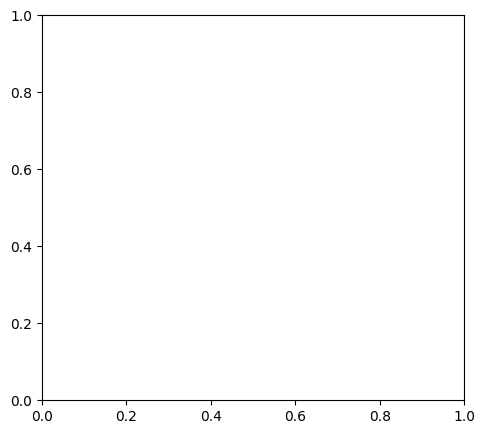

In [3]:
try:
    print("Cargando el mejor modelo guardado (best_model.pth) para los gráficos...")
    model.load_state_dict(torch.load('best_model.pth'))
except:
    print("No se encontró 'best_model.pth'. Usando el último modelo.")

# --- Gráfico 1: Pérdida (Loss) vs. Épocas ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Pérdida (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Gráfico 2: Precisión (Accuracy) vs. Épocas ---
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Precisión (Accuracy) por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Guardar el gráfico de resultados (similar a results.png de YOLO)
plt.savefig('grafico_resultados.png')
print("Gráfico 'grafico_resultados.png' guardado.")
plt.show()


# --- Gráfico 3: Matriz de Confusión (Confusion Matrix) ---
# Necesitamos recalcular las predicciones sobre el conjunto de validación
print("\nGenerando Matriz de Confusión (usando el conjunto de validación)...")

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in valid_loader: # Usamos valid_loader
        if -1 in labels:
            continue
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy()) # Guardar predicciones
        all_labels.extend(labels.cpu().numpy())   # Guardar etiquetas reales

# Nombres de las clases (tu modelo tiene 15 salidas)
num_classes = 15 
class_names = [str(i) for i in range(num_classes)] 

# Calcular la matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Graficar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión (Validación)')
plt.ylabel('Etiqueta Real (True Label)')
plt.xlabel('Predicción (Predicted Label)')

# Guardar la matriz (similar a confusion_matrix.png de YOLO)
plt.savefig('matriz_confusion.png')
print("Gráfico 'matriz_confusion.png' guardado.")
plt.show()

In [ ]:
# --- Configuración de rutas para test ---
IMAGEN_DIR_TEST = os.path.join(KAGGLE_DOWNLOAD_PATH, 'car', 'test', 'images') 
ETIQUETAS_DIR_TEST = os.path.join(KAGGLE_DOWNLOAD_PATH, 'car', 'test', 'labels')
CSV_SALIDA_TEST = 'yolo_labels_test.csv'

# Definir las rutas usando la ruta de descarga de Kaggle
ruta_csv_test = os.path.join(DATA_DIR, CSV_SALIDA_TEST) # El CSV se creó en el directorio actual
# IMPORTANTE: Definir la ruta de imágenes APUNTANDO al subdirectorio 'train/images'
ruta_imgs_test = os.path.join(KAGGLE_DOWNLOAD_PATH, 'car', 'test', 'images') 

# Crear DataLoader de test
dataset_yolo_test = YOLODataset(archivo_csv=ruta_csv_test, directorio_imagenes=ruta_imgs_test, transform=transform)
test_loader = DataLoader(dataset_yolo_test, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTest DataLoader creado con {len(test_loader)} batches")



Test DataLoader creado con 40 batches


In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Evaluación de la red
def evaluate(model, test_loader):
    model.eval()  # Poner el modelo en modo evaluación
    correct = 0
    total = test_loader.dataset.__len__()  # Total de muestras en el conjunto de test
    print(f'Total de muestras en el conjunto de test: {total}')
    with torch.no_grad():  # No calcular gradientes
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)  # Mover datos al dispositivo
            outputs = model(inputs)  # Forward pass
            _, predicted = torch.max(outputs.data, 1)  # Obtener las predicciones
            correct += (predicted == labels).sum().item()  # Actualizar el contador de aciertos
    accuracy = 100 * correct / total if total > 0 else 0
    print(f'Accuracy: {accuracy:.2f}%')

In [ ]:
evaluate(model, test_loader)

Total de muestras en el conjunto de test: 637
Accuracy: 51.65%
